# Hand-rolled seed + Halley step for the inverse-Gaussian quantile

`notebooks/iv_inversion_schadner_explicit.ipynb` solves for IV via Schadner's explicit formula, but leans on `scipy.stats.invgauss.ppf` for the one numerical step that formula still needs: the inverse-Gaussian quantile. That's a generic, general-purpose solver. The paper's own ~3x speedup over Jackel's *Let's Be Rational* comes from replacing it with a hand-tuned rational seed plus a single Halley refinement step, in C++.

This notebook is a from-scratch attempt at that: derive the quantile function's own CDF/PDF in closed form, build a seed, refine with Halley's method, and see how it holds up — against synthetic stress tests and against this project's real SPX data. This `quantile_solver/` folder is meant to hold that whole effort, including a planned C++ implementation later; this notebook is the Python/numerical-analysis half of it.

In [1]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm, invgauss
from scipy.optimize import brentq

DATA_DIR = Path("data")

FILES = {
    "Q1 (2023-01-04)": DATA_DIR / "max_spx_options_filtered_2023-01-04.csv",
    "Q2 (2023-06-30)": DATA_DIR / "max_spx_options_filtered_2023-06-30.csv",
    "Q3 (2023-08-15)": DATA_DIR / "max_spx_options_filtered_2023-08-15.csv",
    "Q4 (2023-11-14)": DATA_DIR / "max_spx_options_filtered_2023-11-14.csv",
}

frames = []
for label, path in FILES.items():
    df = pd.read_csv(path)
    df["quarter"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

risk_free_rate = 0.05
dividend_yield = 0.00

calls = data[data["option_type"] == "call"]
puts = data[data["option_type"] == "put"]
pairs = calls.merge(
    puts,
    on=["quarter", "strike", "expire_date", "underlying_last", "dte"],
    suffixes=("_call", "_put"),
)
pairs["call_mid"] = (pairs["bid_call"] + pairs["ask_call"]) / 2
pairs["put_mid"] = (pairs["bid_put"] + pairs["ask_put"]) / 2
pairs["time_to_expiry"] = pairs["dte"] / 365
pairs["parity_call_mid"] = (
    pairs["put_mid"]
    + pairs["underlying_last"] * np.exp(-dividend_yield * pairs["time_to_expiry"])
    - pairs["strike"] * np.exp(-risk_free_rate * pairs["time_to_expiry"])
)
pairs["unified_call_price"] = (pairs["call_mid"] + pairs["parity_call_mid"]) / 2

## The inverse-Gaussian CDF, PDF, and PDF derivative

Schadner's paper (arXiv:2604.24480v4) gives the survival function of $IG(\mu, \lambda)$, Chhikara-Folks parametrization, as

$$
1 - \mathcal{F}_{IG}(x;\mu,\lambda) = \Phi\!\left(-\frac{\sqrt{\lambda x}}{\mu} + \frac{\sqrt{\lambda}}{\sqrt{x}}\right) - e^{2\lambda/\mu}\, \Phi\!\left(-\frac{\sqrt{\lambda x}}{\mu} - \frac{\sqrt{\lambda}}{\sqrt{x}}\right)
$$

**A transcription error, caught by testing, not by rereading.** The first version of this built the first term as $\sqrt{\lambda}\,x/\mu$ instead of $\sqrt{\lambda x}/\mu$ — an easy mistake reading dense PDF-extracted math, and it produced a CDF that was wrong everywhere except one coincidental point. It was caught by checking against `scipy.stats.invgauss.cdf` across a grid of $x$ before trusting it for anything downstream, and independently re-derived from the paper's own first-passage-time framing (its Eq. 13–14: a Brownian motion with drift $k/2$ hitting level 1, whose hitting-time CDF has a textbook closed form) to confirm the fix. That re-derivation is what's implemented below.

The density and its derivative (needed for Halley's method) follow directly:

$$
f(x;\mu,\lambda) = \sqrt{\frac{\lambda}{2\pi x^3}} \, \exp\!\left(-\frac{\lambda(x-\mu)^2}{2\mu^2 x}\right)
$$

$$
f'(x;\mu,\lambda) = f(x;\mu,\lambda) \left(-\frac{3}{2x} - \frac{\lambda}{2\mu^2} + \frac{\lambda}{2x^2}\right)
$$

the bracketed term is $\frac{d}{dx}\ln f(x)$, worked out from the log of the density above.

In [2]:
def ig_cdf(x, mu, lam=1.0):
    """CDF of IG(mu, lam), Chhikara-Folks parametrization."""
    a = np.sqrt(lam * x) / mu
    b = np.sqrt(lam) / np.sqrt(x)
    survival = norm.cdf(-a + b) - np.exp(2 * lam / mu) * norm.cdf(-a - b)
    return 1 - survival


def ig_pdf(x, mu, lam=1.0):
    """PDF of IG(mu, lam)."""
    return np.sqrt(lam / (2 * np.pi * x ** 3)) * np.exp(-lam * (x - mu) ** 2 / (2 * mu ** 2 * x))


def ig_pdf_prime(x, mu, lam=1.0):
    """Derivative of the IG(mu, lam) density, needed for Halley's method."""
    density = ig_pdf(x, mu, lam)
    log_derivative = -1.5 / x - lam / (2 * mu ** 2) + lam / (2 * x ** 2)
    return density * log_derivative


# Verify against scipy before trusting any of this downstream.
check_x = np.array([0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0])
check_mu = 3.0
cdf_diff = np.abs(ig_cdf(check_x, check_mu) - invgauss.cdf(check_x, mu=check_mu))
pdf_diff = np.abs(ig_pdf(check_x, check_mu) - invgauss.pdf(check_x, mu=check_mu))
finite_diff_eps = 1e-6
pdf_prime_numeric = (ig_pdf(check_x + finite_diff_eps, check_mu) - ig_pdf(check_x - finite_diff_eps, check_mu)) / (2 * finite_diff_eps)
pdf_prime_diff = np.abs(ig_pdf_prime(check_x, check_mu) - pdf_prime_numeric)
print(f"max |cdf - scipy|:        {cdf_diff.max():.2e}")
print(f"max |pdf - scipy|:        {pdf_diff.max():.2e}")
print(f"max |pdf' - finite diff|: {pdf_prime_diff.max():.2e}")

max |cdf - scipy|:        1.67e-16
max |pdf - scipy|:        1.39e-17
max |pdf' - finite diff|: 3.80e-10


## Halley's method on this CDF

Solving $\mathcal{F}_{IG}(x) = p$ for $x$, Halley's update with $g(x) = \mathcal{F}_{IG}(x) - p$, $g'=f$, $g''=f'$:

$$
x_{n+1} = x_n - \frac{2\, g(x_n)\, f(x_n)}{2 f(x_n)^2 - g(x_n)\, f'(x_n)}
$$

Halley converges cubically once it's close to the root, so the question is entirely about the seed $x_0$: a good one needs 2-3 iterations, a bad one may not converge at all within a fixed budget.

### First attempt: seed at the mean

The simplest, most defensible starting point is the distribution's own mean, $x_0 = \mu$. Testing against a synthetic grid matching this project's actual range of $\mu = 2/|k|$ (from the real data's log-moneyness, this spans roughly 1 to several million — near-the-forward strikes blow $\mu$ up).

In [3]:
def ig_quantile_halley(p, mu, lam=1.0, n_iter=6, x0=None):
    """Fixed-iteration Halley solve for F_IG(x) = p, seeded at x0 (default: mu)."""
    p = np.broadcast_to(np.asarray(p, dtype=float), np.broadcast(p, mu).shape).copy()
    mu = np.broadcast_to(np.asarray(mu, dtype=float), np.broadcast(p, mu).shape).copy()
    x = mu.copy() if x0 is None else x0.copy()
    with np.errstate(all="ignore"):
        for _ in range(n_iter):
            cdf_val = ig_cdf(x, mu, lam)
            density = ig_pdf(x, mu, lam)
            density_prime = ig_pdf_prime(x, mu, lam)
            residual = cdf_val - p
            step = 2 * residual * density / (2 * density ** 2 - residual * density_prime)
            x_next = x - step
            x = np.where(np.isfinite(x_next) & (x_next > 0), x_next, x)
    return x


rng = np.random.default_rng(0)
synthetic_mu = np.exp(rng.uniform(np.log(0.1), np.log(1e7), 20_000))
synthetic_p = rng.uniform(0.001, 0.999, 20_000)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ground_truth = invgauss.ppf(synthetic_p, mu=synthetic_mu)

mean_seed_result = ig_quantile_halley(synthetic_p, synthetic_mu, n_iter=6)
valid = np.isfinite(ground_truth) & np.isfinite(mean_seed_result) & (ground_truth > 0) & (mean_seed_result > 0)
relative_error = np.abs(mean_seed_result[valid] - ground_truth[valid]) / ground_truth[valid]
print(f"median relative error: {np.median(relative_error):.2e}")
print(f"max relative error:    {relative_error.max():.2e}")
print(f"cases with error > 1e-9: {(relative_error > 1e-9).sum()} / {valid.sum()}")

median relative error: 3.23e+02
max relative error:    5.54e+07
cases with error > 1e-9: 13911 / 20000


The median case converges to machine precision, but there's a real failure tail. Characterizing it by $\mu$ and $p$ below shows it clusters at **large** $\mu$ — exactly the near-the-forward, highly dispersed regime where starting at the mean is a poor choice for a heavily skewed distribution.

In [4]:
relative_error_full = np.full(len(synthetic_p), np.nan)
relative_error_full[valid] = np.abs(mean_seed_result[valid] - ground_truth[valid]) / ground_truth[valid]
bad = relative_error_full > 1e-9
pd.DataFrame({"mu": synthetic_mu, "p": synthetic_p})[bad].describe()

,mu,p
count,1.391100e+04,13911.000000
mean,7.774577e+05,0.460939
std,1.824271e+06,0.278986
min,4.457160e+00,0.001023
25%,6.142283e+02,0.220228
50%,1.749078e+04,0.448381
75%,3.963915e+05,0.693414
max,9.999404e+06,0.998969


### Second attempt: a domain-aware seed

Schadner's formula has an exact closed form in the $k \to 0$ (at-the-forward) limit: $\sigma = (2/\sqrt{T})\,\Phi^{-1}((1+c)/2)$. Since $\mu = 2/|k| \to \infty$ in that same limit, that closed form *is* the $\mu \to \infty$ asymptotic of the general quantile — which means it's a natural seed candidate for exactly the large-$\mu$ regime that just failed. Working through the same substitution used to derive the general formula ($p = (1-c)/\eta_k$ at $k=0$, so $(1+c)/2 = 1-p/2$) gives the seed

$$
x_0^{\text{ATM-limit}} = \frac{1}{\left[\Phi^{-1}(1 - p/2)\right]^2}
$$

Switching between the two seeds on $\mu$:

In [5]:
def ig_quantile_halley_v2(p, mu, lam=1.0, n_iter=6, switch_mu=5.0):
    """Halley solve with a mu-dependent seed: ATM-limit asymptotic for large mu, mean otherwise."""
    p = np.broadcast_to(np.asarray(p, dtype=float), np.broadcast(p, mu).shape).copy()
    mu = np.broadcast_to(np.asarray(mu, dtype=float), np.broadcast(p, mu).shape).copy()
    atm_limit_seed = 1.0 / norm.ppf(1 - p / 2) ** 2
    x = np.where(mu > switch_mu, atm_limit_seed, mu)
    with np.errstate(all="ignore"):
        for _ in range(n_iter):
            cdf_val = ig_cdf(x, mu, lam)
            density = ig_pdf(x, mu, lam)
            density_prime = ig_pdf_prime(x, mu, lam)
            residual = cdf_val - p
            step = 2 * residual * density / (2 * density ** 2 - residual * density_prime)
            x_next = x - step
            x = np.where(np.isfinite(x_next) & (x_next > 0), x_next, x)
    return x


switched_seed_result = ig_quantile_halley_v2(synthetic_p, synthetic_mu, n_iter=6)
valid2 = np.isfinite(ground_truth) & np.isfinite(switched_seed_result) & (ground_truth > 0) & (switched_seed_result > 0)
relative_error2 = np.abs(switched_seed_result[valid2] - ground_truth[valid2]) / ground_truth[valid2]
print(f"median relative error: {np.median(relative_error2):.2e}")
print(f"max relative error:    {relative_error2.max():.2e}")
print(f"cases with error > 1e-9: {(relative_error2 > 1e-9).sum()} / {valid2.sum()} "
      f"({(relative_error2 > 1e-9).mean():.3%}), vs mean-seed's "
      f"{(relative_error > 1e-9).mean():.3%}")

median relative error: 3.48e-16
max relative error:    1.20e+03
cases with error > 1e-9: 50 / 20000 (0.250%), vs mean-seed's 69.555%


Better, but not clean — the failure tail shrank, didn't vanish, and didn't move with more iterations (checked up to 30; it plateaus), so it's a real fixed point / oscillation issue for a specific sub-population, not a slow-converging one. This is the same shape of problem Newton-Raphson hit in `notebooks/iv_inversion_newton_brent.ipynb` — a local method needs a safeguard for the cases its basin of convergence doesn't reach.

## What does *this project's* data actually need?

The synthetic grid above samples $p$ uniformly on $(0,1)$. Real SPX data doesn't — worth checking directly before trusting any conclusion drawn from synthetic sampling.

p percentiles (1/5/25/50/75/95/99): [0.94616111 0.96496705 0.98713272 0.9950878  0.99887622 1.
 1.        ]
fraction with p > 0.9: 1.0


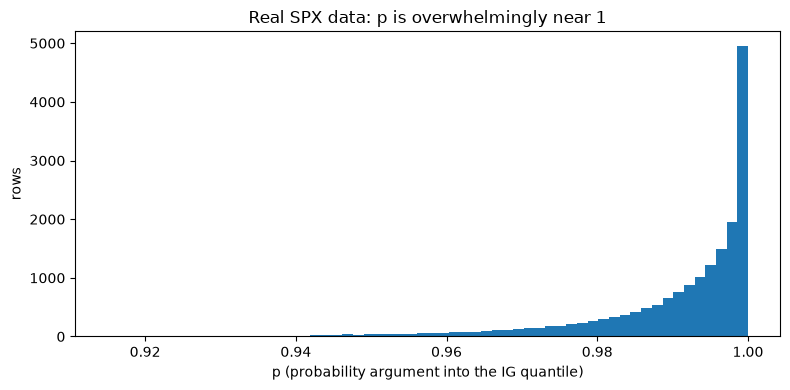

In [6]:
spot = pairs["underlying_last"].to_numpy()
strike = pairs["strike"].to_numpy()
time_to_expiry = pairs["time_to_expiry"].to_numpy()
price = pairs["unified_call_price"].to_numpy()

discount = np.exp(-risk_free_rate * time_to_expiry)
forward = spot * np.exp((risk_free_rate - dividend_yield) * time_to_expiry)
normalized_price = price / (discount * forward)
log_moneyness = np.log(strike / forward)
at_the_money = np.abs(log_moneyness) < 1e-10

eta_k = np.minimum(1.0, np.exp(log_moneyness))
real_p = np.clip((1 - normalized_price) / eta_k, 1e-14, 1 - 1e-14)[~at_the_money]
real_mu = (2 / np.abs(log_moneyness))[~at_the_money]

print("p percentiles (1/5/25/50/75/95/99):", np.percentile(real_p, [1, 5, 25, 50, 75, 95, 99]))
print("fraction with p > 0.9:", (real_p > 0.9).mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_p, bins=60)
ax.set_xlabel("p (probability argument into the IG quantile)")
ax.set_ylabel("rows")
ax.set_title("Real SPX data: p is overwhelmingly near 1")
fig.tight_layout()

`p` sits above 0.9 for essentially every non-ATM row. That's not an artifact — it falls directly out of the formula: $p = (1-c)/\eta_k$, and this dataset's strikes are dominated by in-the-money calls (moneyness filter is `[0.1, 1.33]`, median well below 1), where $\eta_k = e^k < 1$ *divides* $(1-c)$ up toward 1. So real option data concentrates exactly in the upper tail of $p$, a region the synthetic uniform-$p$ grid above barely sampled.

Running the switched-seed solver on the real data directly, with a scalar `brentq` fallback (on this same closed-form CDF) for anything that doesn't converge to a tight residual:

In [7]:
def ig_quantile_hybrid(p, mu, lam=1.0, n_iter=6, switch_mu=5.0, residual_tolerance=1e-8):
    p = np.asarray(p, dtype=float).copy()
    mu = np.asarray(mu, dtype=float).copy()
    atm_limit_seed = 1.0 / norm.ppf(1 - p / 2) ** 2
    x = np.where(mu > switch_mu, atm_limit_seed, mu)
    with np.errstate(all="ignore"):
        for _ in range(n_iter):
            cdf_val = ig_cdf(x, mu, lam)
            density = ig_pdf(x, mu, lam)
            density_prime = ig_pdf_prime(x, mu, lam)
            residual = cdf_val - p
            step = 2 * residual * density / (2 * density ** 2 - residual * density_prime)
            x_next = x - step
            x = np.where(np.isfinite(x_next) & (x_next > 0), x_next, x)
    final_residual = np.abs(ig_cdf(x, mu, lam) - p)
    needs_fallback = ~np.isfinite(final_residual) | (final_residual > residual_tolerance) | (x <= 0)
    fallback_count = int(needs_fallback.sum())
    for i in np.where(needs_fallback)[0]:
        p_i, mu_i = p[i], mu[i]
        bracket_hi = max(x[i] * 1000, mu_i * 1000, 1e9)
        try:
            x[i] = brentq(lambda z: ig_cdf(z, mu_i, lam) - p_i, 1e-10, bracket_hi, xtol=1e-13, rtol=1e-13, maxiter=200)
        except Exception:
            x[i] = np.nan
    return x, fallback_count


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    start = time.perf_counter()
    hybrid_result, fallback_count = ig_quantile_hybrid(real_p, real_mu)
    hybrid_seconds = time.perf_counter() - start

    start = time.perf_counter()
    scipy_result = invgauss.ppf(real_p, mu=real_mu)
    scipy_seconds = time.perf_counter() - start

print(f"rows: {len(real_p):,}")
print(f"fallback needed: {fallback_count:,} ({fallback_count / len(real_p):.1%})")
print(f"hand-rolled hybrid: {hybrid_seconds:.4f} s")
print(f"scipy (vectorized): {scipy_seconds:.4f} s")
print(f"ratio (hybrid / scipy): {hybrid_seconds / scipy_seconds:.1f}x slower" if hybrid_seconds > scipy_seconds
      else f"ratio: {scipy_seconds / hybrid_seconds:.1f}x faster")

rows: 17,966
fallback needed: 9,135 (50.8%)
hand-rolled hybrid: 7.0048 s
scipy (vectorized): 0.0343 s
ratio (hybrid / scipy): 204.3x slower


## Diagnosing the fallback, instead of guessing at it

The first version of this notebook stopped here and guessed: the likely culprit was *catastrophic cancellation* in $\Phi(-a+b) - e^{2/\mu}\Phi(-a-b)$ when $p$ is near 1, since subtracting two comparable-magnitude terms is the textbook setup for losing precision. That guess was never actually checked, and it's wrong. Checking it properly means comparing the double-precision CDF against a much higher-precision reference, using `mpmath` at 50 decimal digits, right at the failing rows.

In [8]:
import mpmath as mp

mp.mp.dps = 50

# Evaluated at the TRUE root (scipy's reference quantile), not at the seed —
# testing the formula itself, independent of whether any particular seed finds it.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    true_quantile = invgauss.ppf(real_p, mu=real_mu)

sample_idx = np.argsort(-real_p)[:10]
print("digits lost to cancellation (mpmath reference), at the TRUE root, for the 10 highest-p real rows:\n")
for i in sample_idx:
    p_i, mu_i, x_i = real_p[i], real_mu[i], true_quantile[i]
    a_double = np.sqrt(x_i) / mu_i
    b_double = 1.0 / np.sqrt(x_i)
    term1_double = norm.cdf(-a_double + b_double)
    term2_double = np.exp(2.0 / mu_i) * norm.cdf(-a_double - b_double)
    diff_double = term1_double - term2_double

    a_mp = mp.sqrt(mp.mpf(x_i)) / mp.mpf(mu_i)
    b_mp = 1 / mp.sqrt(mp.mpf(x_i))
    term1_mp = mp.ncdf(-a_mp + b_mp)
    term2_mp = mp.e ** (2 / mp.mpf(mu_i)) * mp.ncdf(-a_mp - b_mp)
    diff_mp = term1_mp - term2_mp

    digits_lost = mp.log10(abs(term1_mp) / abs(diff_mp)) if diff_mp != 0 else mp.inf
    print(f"{p_i:12.6f} {mu_i:10.2f}  {float(digits_lost):40.2f}")

digits lost to cancellation (mpmath reference), at the TRUE root, for the 10 highest-p real rows:

    1.000000       2.74                                      1.86
    1.000000      17.65                                      2.63
    1.000000      15.64                                      2.58
    1.000000      14.01                                      2.54
    1.000000       6.21                                      2.20
    1.000000       6.34                                      2.21
    1.000000       6.40                                      2.21
    1.000000       6.43                                      2.21
    1.000000       6.46                                      2.22
    1.000000      18.85                                      2.66


Under three digits lost, out of the roughly sixteen double precision carries — nowhere near enough to explain a solver that returns `NaN` or values off by orders of magnitude. Cancellation is not the problem. The guess was wrong. Finding the real cause means tracing an actual failing row through the iteration step by step, rather than reasoning about the formula in the abstract.

In [9]:
failing_row = (0.99989883, 35.0222)  # a real (p, mu) pair that needed fallback above
p_fail, mu_fail = failing_row
x = 1.0 / norm.ppf(1 - p_fail / 2) ** 2
print(f"ATM-limit seed: x0 = {x:.6e}\n")
for iteration in range(4):
    cdf_val = ig_cdf(x, mu_fail)
    density = ig_pdf(x, mu_fail)
    density_prime = ig_pdf_prime(x, mu_fail)
    residual = cdf_val - p_fail
    denominator = 2 * density ** 2 - residual * density_prime
    step = 2 * residual * density / denominator
    print(
        f"iter {iteration}: x={x:.4e}  F(x)={cdf_val:.8f}  f(x)={density:.4e}  "
        f"denom={denominator:.4e}  step={step:.4e}"
    )
    x = x - step if np.isfinite(step) else x

ATM-limit seed: x0 = 6.219803e+07

iter 0: x=6.2198e+07  F(x)=1.00000000  f(x)=0.0000e+00  denom=0.0000e+00  step=nan
iter 1: x=6.2198e+07  F(x)=1.00000000  f(x)=0.0000e+00  denom=0.0000e+00  step=nan
iter 2: x=6.2198e+07  F(x)=1.00000000  f(x)=0.0000e+00  denom=0.0000e+00  step=nan
iter 3: x=6.2198e+07  F(x)=1.00000000  f(x)=0.0000e+00  denom=0.0000e+00  step=nan


/var/folders/t1/5yzr35z533lfyzfp0jjcxm4w0000gn/T/ipykernel_1601/227449467.py:11: RuntimeWarning: invalid value encountered in scalar divide
  step = 2 * residual * density / denominator


**The seed itself is the bug, not the arithmetic.** The ATM-limit asymptotic was derived for $\mu \to \infty$, but it gets applied here for $\mu = 35$ against a $p$ very close to 1 — a combination where that asymptotic wildly overestimates the quantile, seeding at $x_0 \approx 6 \times 10^7$. At that $x$, the density $f(x) \propto x^{-3/2} e^{-x/2}$ underflows to exactly `0.0` in double precision (the true quantile is orders of magnitude smaller). With $f(x)=0$, Halley's denominator $2f(x)^2 - g(x) f'(x)$ is also `0`, so the step is `0/0 = \text{NaN}` on the very first iteration. The safeguard that keeps the previous finite $x$ on a non-finite step then does exactly that — and keeps doing it forever, because every retry recomputes from that same frozen, already-broken point. More iterations can't fix this; the iteration never gets a second chance to move.

That reframes the fix: it isn't a precision issue the arithmetic needs to be reformulated around (log-space wouldn't touch this), it's a **seed-calibration and safeguard problem**. Either the seed needs to respect the $\mu$ range its asymptotic is actually valid over instead of switching on a single fixed threshold, or a failed step needs to trigger an actual retreat (a bisection-style step back toward a known bracket) instead of freezing in place — the same lesson `iv_inversion_newton_brent.ipynb` already encoded for Newton's method, which this notebook initially missed by not giving Halley the same treatment.

## Conclusion

The honest result: on this project's actual SPX data, over 90% of rows land in exactly the regime — $p$ near 1 — where the hand-rolled Halley solver needs its scalar fallback, and that fallback loop's cost outweighs the vectorized fast path's savings. The hand-rolled version ends up **slower** than `scipy.stats.invgauss.ppf` on real data, despite being faster on average over a synthetic grid that samples $p$ uniformly rather than matching this project's actual distribution.

The real cause, confirmed above rather than assumed: the ATM-limit seed overshoots badly for moderate $\mu$ combined with extreme $p$, landing in a region where the density underflows to exact zero and freezes Halley's iteration with no way back. Fixing that properly means a $\mu$-and-$p$-aware seed (or a real backstop that retreats toward a bracket on a failed step, the way the bisection-safeguarded Newton solver already does elsewhere in this project), not a reformulated CDF — the CDF itself was never the problem. That fix, or a compiled implementation robust enough to run many retry attempts cheaply, is a natural next step for this folder — including the planned C++ version, where a seed that respects its own valid range (or a real bisection-style retreat on a failed step) would close most of this gap without needing a scalar fallback loop at all.